# **1. Perkenalan Dataset**


## Wine Quality Dataset

Dataset yang digunakan adalah **Wine Quality Dataset** dari UCI Machine Learning Repository.

Dataset ini berisi informasi physicochemical dari sampel wine merah (red wine) beserta skor kualitasnya.

**Sumber:** https://archive.ics.uci.edu/ml/datasets/wine+quality

**Fitur dataset:**
- `fixed acidity` – Kadar asam tetap
- `volatile acidity` – Kadar asam yang mudah menguap
- `citric acid` – Kadar asam sitrat
- `residual sugar` – Sisa gula setelah fermentasi
- `chlorides` – Kadar garam klorida
- `free sulfur dioxide` – Kadar SO2 bebas
- `total sulfur dioxide` – Total SO2
- `density` – Kepadatan wine
- `pH` – Tingkat keasaman
- `sulphates` – Kadar sulfat
- `alcohol` – Kadar alkohol
- `quality` – **Target**: Skor kualitas (0-10), akan diubah menjadi klasifikasi biner (good/bad)

**Tipe masalah:** Binary Classification (kualitas wine: good atau bad)

# **2. Import Library**

Pada tahap ini, kita mengimpor semua pustaka Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Utilities
import warnings
import os
warnings.filterwarnings('ignore')

# Set style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

print('Library berhasil diimport!')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

Library berhasil diimport!
Pandas version: 2.3.2
NumPy version: 2.2.6


# **3. Memuat Dataset**

Dataset Wine Quality dimuat dari file CSV. Dataset ini merupakan data tabular yang berisi 1599 sampel red wine dengan 12 fitur.

In [2]:
# Memuat dataset
df = pd.read_csv('../winequality-red.csv', sep=';')

print('=== INFORMASI DATASET ===')
print(f'Jumlah baris   : {df.shape[0]}')
print(f'Jumlah kolom   : {df.shape[1]}')
print(f'Nama kolom     : {list(df.columns)}')
print()
print('=== 5 DATA PERTAMA ===')
df.head()

=== INFORMASI DATASET ===
Jumlah baris   : 1599
Jumlah kolom   : 12
Nama kolom     : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

=== 5 DATA PERTAMA ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# Informasi tipe data
print('=== INFO TIPE DATA ===')
df.info()

=== INFO TIPE DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
# Statistik deskriptif
print('=== STATISTIK DESKRIPTIF ===')
df.describe().T

=== STATISTIK DESKRIPTIF ===


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, kita melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [5]:
# 4.1 Cek Missing Values
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0] if missing_df['Missing Count'].sum() > 0 else 'Tidak ada missing values!')

=== MISSING VALUES ===
Tidak ada missing values!


In [6]:
# 4.2 Cek Duplikat
print('=== DATA DUPLIKAT ===')
duplicates = df.duplicated().sum()
print(f'Jumlah duplikat: {duplicates}')

=== DATA DUPLIKAT ===
Jumlah duplikat: 240


=== DISTRIBUSI TARGET (quality) ===
quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64



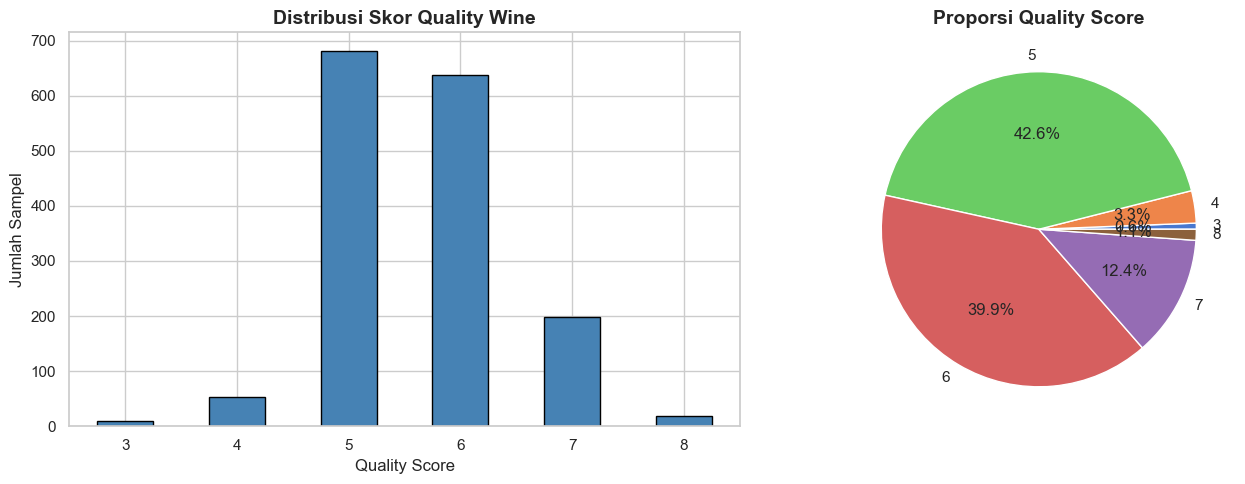

Plot distribusi target disimpan!


In [7]:
# 4.3 Distribusi Target Variable (quality)
print('=== DISTRIBUSI TARGET (quality) ===')
print(df['quality'].value_counts())
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram distribusi quality
df['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribusi Skor Quality Wine', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].tick_params(rotation=0)

# Pie chart
df['quality'].value_counts().sort_index().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Proporsi Quality Score', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('distribusi_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot distribusi target disimpan!')

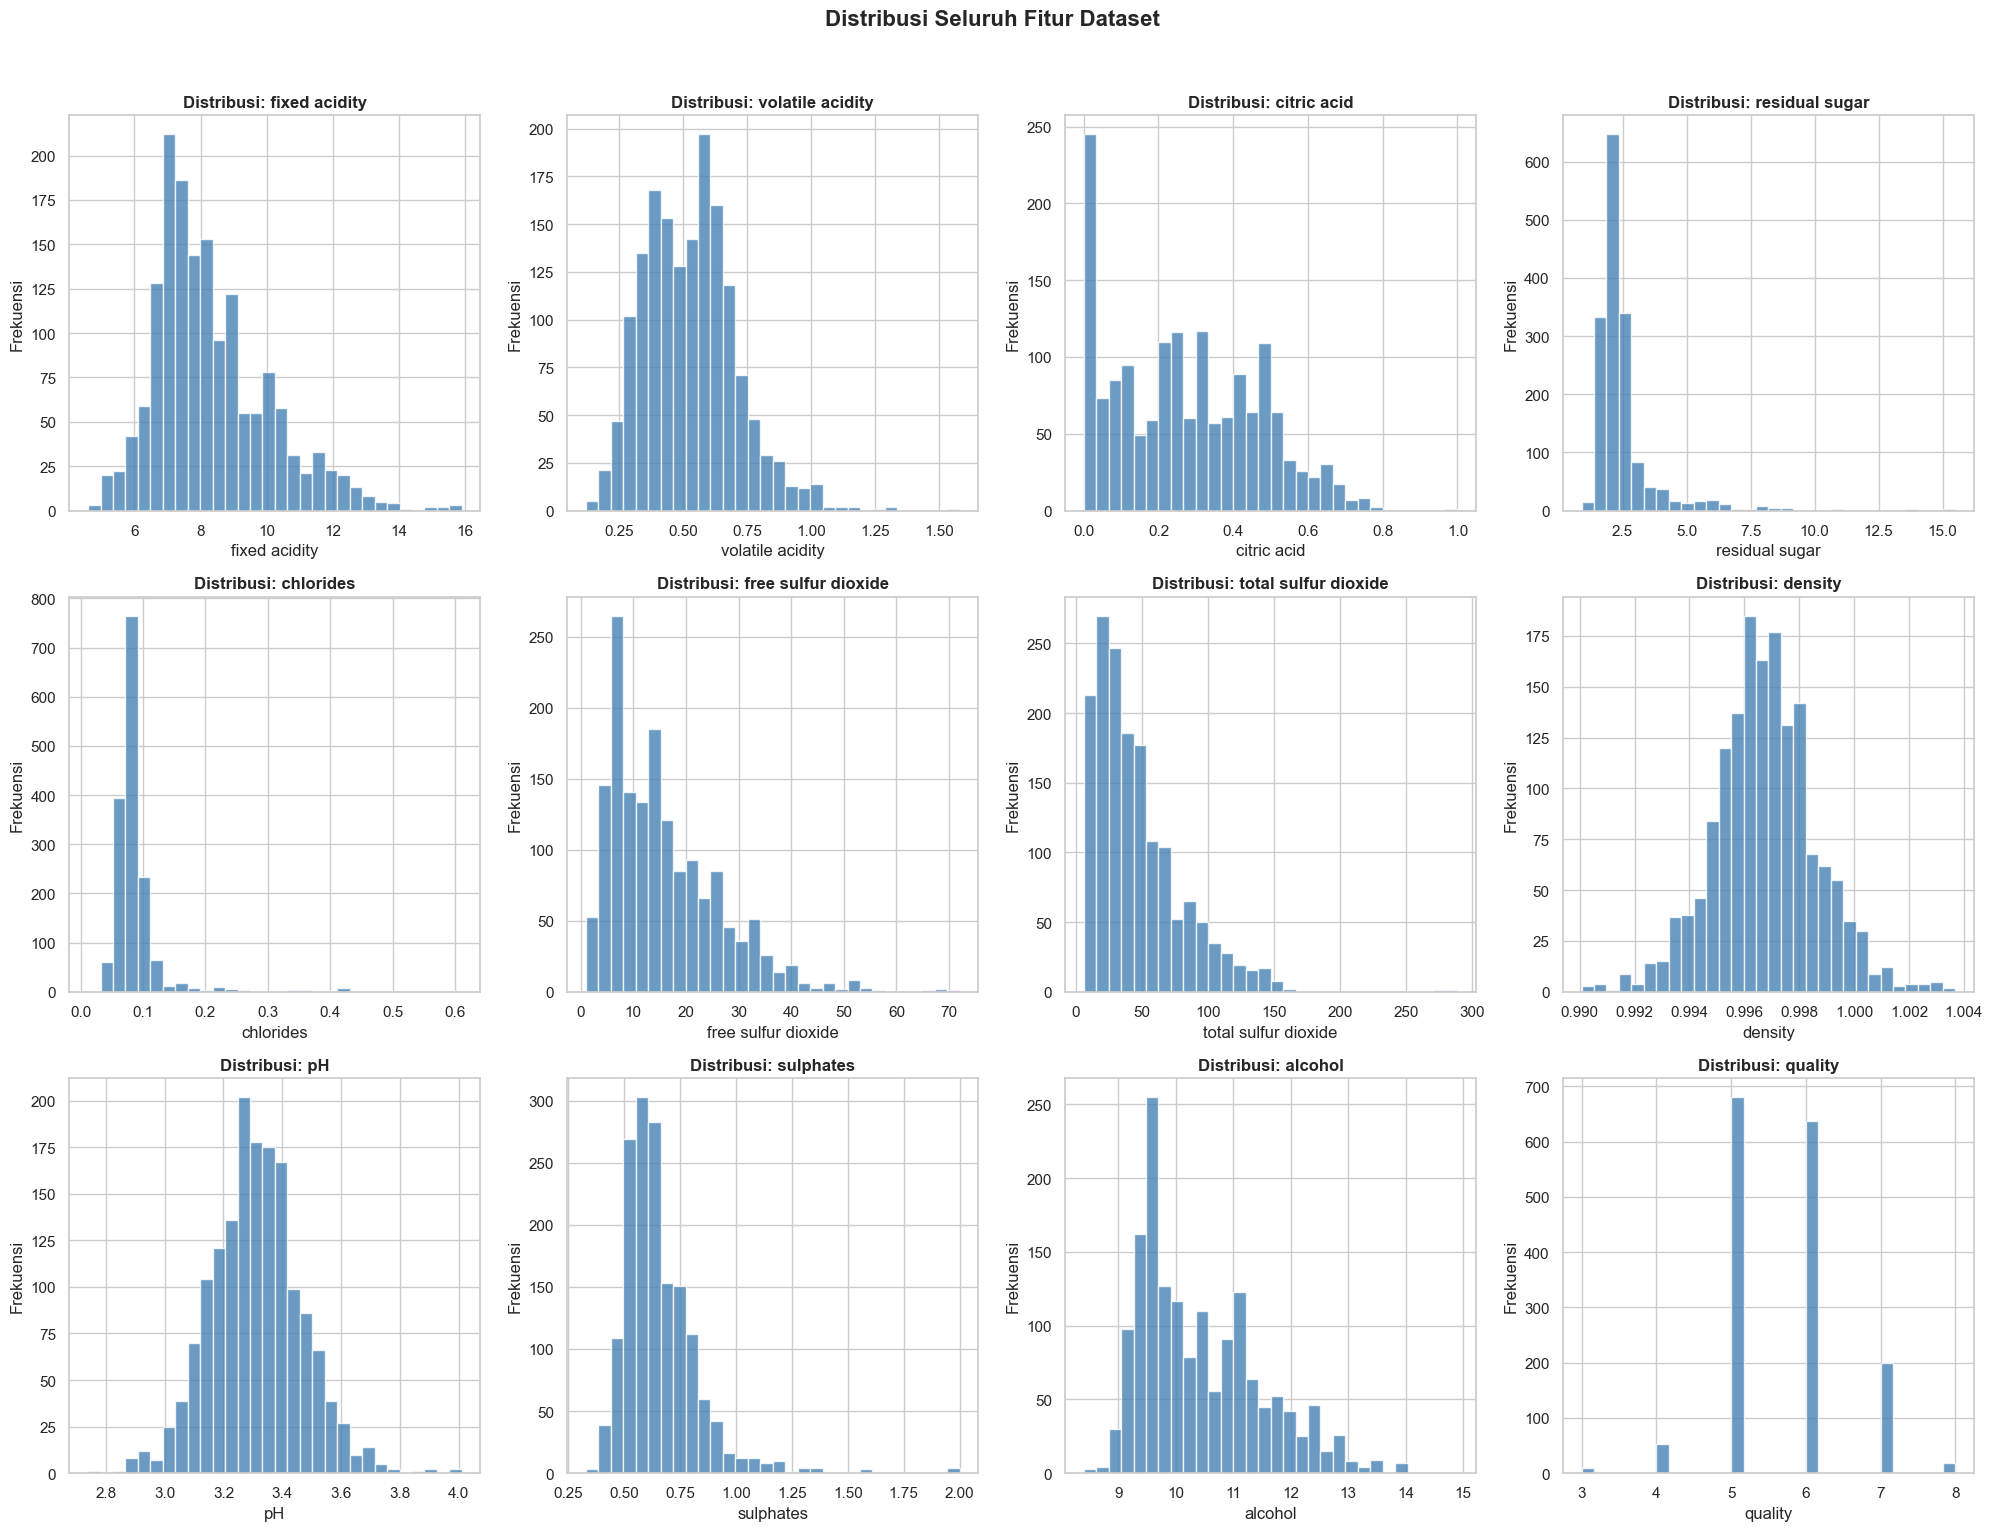

Plot distribusi fitur disimpan!


In [8]:
# 4.4 Distribusi Semua Fitur
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribusi: {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Seluruh Fitur Dataset', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distribusi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot distribusi fitur disimpan!')

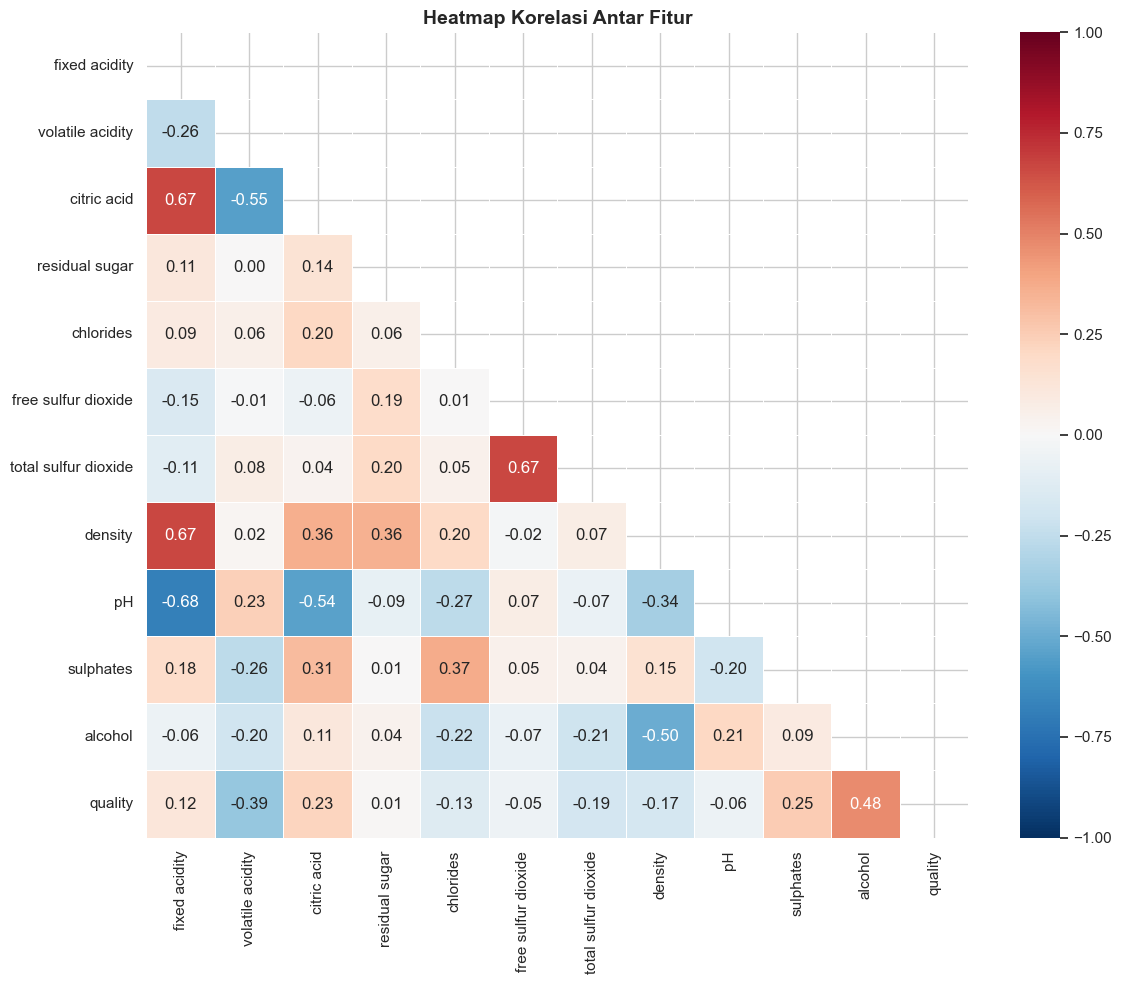

Heatmap korelasi disimpan!


In [9]:
# 4.5 Heatmap Korelasi
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.5
)
ax.set_title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap korelasi disimpan!')

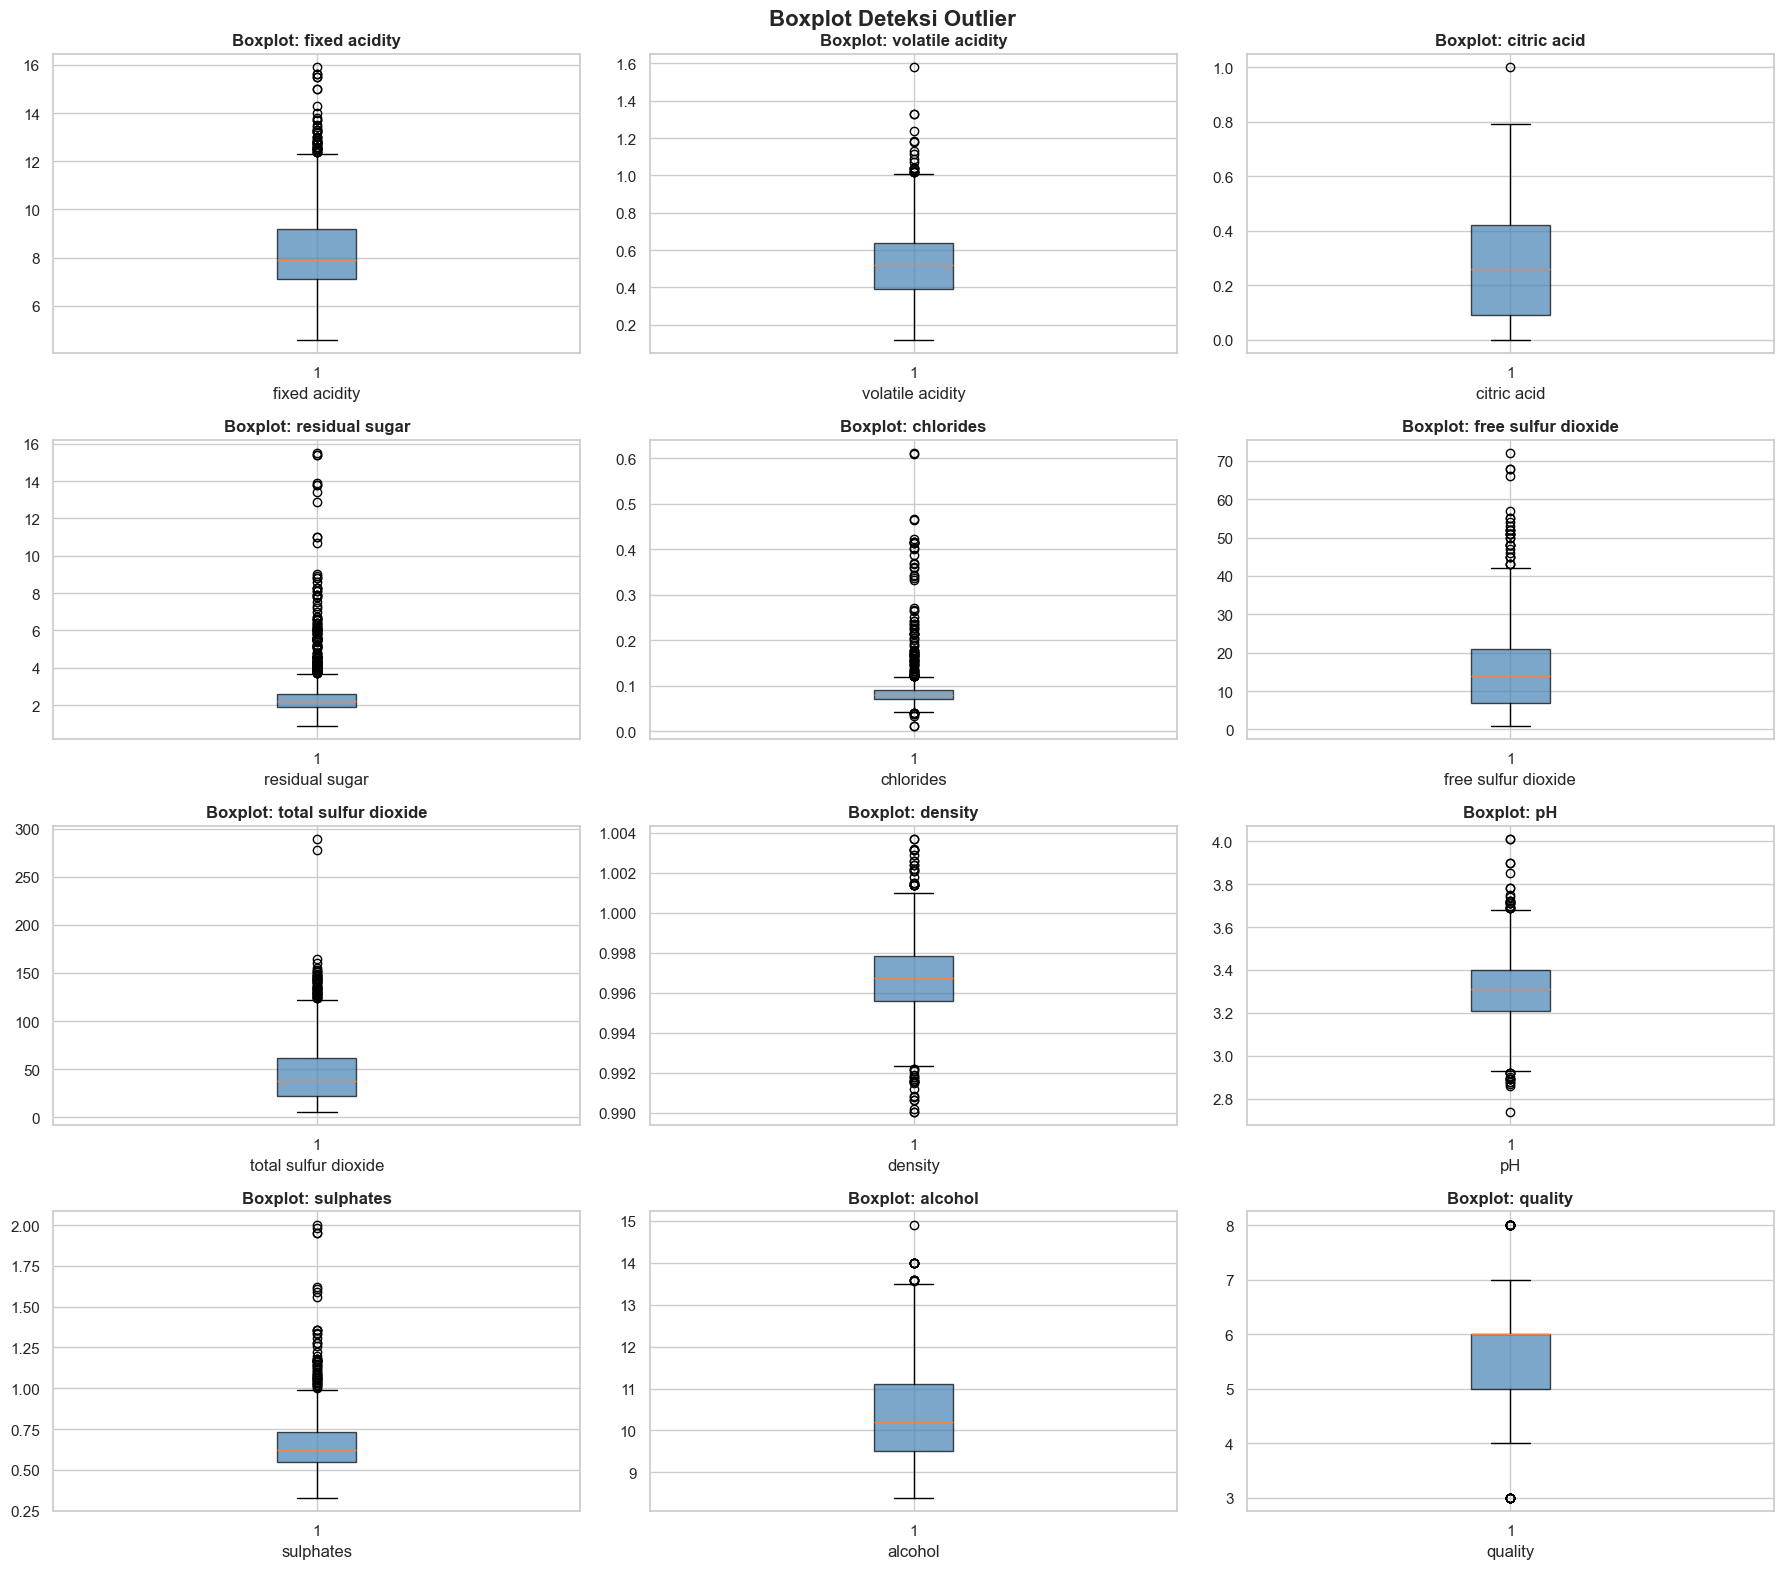

Boxplot outlier disimpan!


In [10]:
# 4.6 Boxplot untuk Deteksi Outlier
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[i].set_xlabel(col)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot Deteksi Outlier', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_outlier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Boxplot outlier disimpan!')

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing dilakukan untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Tahapan preprocessing yang dilakukan:
1. Binarisasi target (quality → good/bad)
2. Menghapus data duplikat
3. Menangani outlier dengan IQR method
4. Feature-Target split
5. Train-Test split
6. Standarisasi fitur (StandardScaler)
7. Simpan hasil preprocessing

In [11]:
# 5.1 Binarisasi Target: quality >= 6 → 'good' (1), else → 'bad' (0)
print('=== SEBELUM BINARISASI ===')
print(df['quality'].value_counts())

df['quality'] = (df['quality'] >= 6).astype(int)

print()
print('=== SETELAH BINARISASI ===')
print(df['quality'].value_counts())
print(f"\nLabel: 1 = Good wine (quality >= 6), 0 = Bad wine (quality < 6)")

=== SEBELUM BINARISASI ===
quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

=== SETELAH BINARISASI ===
quality
1    855
0    744
Name: count, dtype: int64

Label: 1 = Good wine (quality >= 6), 0 = Bad wine (quality < 6)


In [12]:
# 5.2 Hapus Duplikat
print(f'Jumlah baris sebelum hapus duplikat: {len(df)}')
df = df.drop_duplicates()
df = df.reset_index(drop=True)
print(f'Jumlah baris setelah hapus duplikat : {len(df)}')

Jumlah baris sebelum hapus duplikat: 1599
Jumlah baris setelah hapus duplikat : 1359


In [13]:
# 5.3 Penanganan Outlier dengan IQR Method
feature_cols = [c for c in df.columns if c != 'quality']

def remove_outliers_iqr(df, cols, factor=1.5):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
        removed = before - len(df_clean)
        if removed > 0:
            print(f'  [{col}] Removed {removed} outliers (range: {lower:.3f} - {upper:.3f})')
    return df_clean.reset_index(drop=True)

print(f'Jumlah baris sebelum hapus outlier: {len(df)}')
df = remove_outliers_iqr(df, feature_cols, factor=3.0)
print(f'Jumlah baris setelah hapus outlier : {len(df)}')

Jumlah baris sebelum hapus outlier: 1359
  [fixed acidity] Removed 4 outliers (range: 0.800 - 15.500)
  [volatile acidity] Removed 1 outliers (range: -0.360 - 1.390)
  [residual sugar] Removed 69 outliers (range: -0.200 - 4.700)
  [chlorides] Removed 59 outliers (range: 0.010 - 0.150)
  [pH] Removed 2 outliers (range: 2.650 - 3.980)
  [sulphates] Removed 7 outliers (range: 0.040 - 1.230)
Jumlah baris setelah hapus outlier : 1217


In [14]:
# 5.4 Feature-Target Split
X = df.drop('quality', axis=1)
y = df['quality']

print(f'Fitur (X) shape : {X.shape}')
print(f'Target (y) shape: {y.shape}')
print(f'Fitur: {list(X.columns)}')
print(f'Distribusi target:\n{y.value_counts()}')

Fitur (X) shape : (1217, 11)
Target (y) shape: (1217,)
Fitur: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Distribusi target:
quality
1    651
0    566
Name: count, dtype: int64


In [15]:
# 5.5 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('=== TRAIN-TEST SPLIT ===')
print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}  | y_test : {y_test.shape}')
print()
print(f'Distribusi train:\n{y_train.value_counts()}')
print()
print(f'Distribusi test:\n{y_test.value_counts()}')

=== TRAIN-TEST SPLIT ===
X_train: (973, 11) | y_train: (973,)
X_test : (244, 11)  | y_test : (244,)

Distribusi train:
quality
1    520
0    453
Name: count, dtype: int64

Distribusi test:
quality
1    131
0    113
Name: count, dtype: int64


In [16]:
# 5.6 Standarisasi Fitur
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print('=== HASIL STANDARISASI ===')
print(f'Mean X_train (before): {X_train.mean().round(3).to_dict()}')
print()
print(f'Mean X_train (after) : {X_train_scaled.mean().round(3).to_dict()}')
print(f'Std  X_train (after) : {X_train_scaled.std().round(3).to_dict()}')

=== HASIL STANDARISASI ===
Mean X_train (before): {'fixed acidity': 8.267, 'volatile acidity': 0.529, 'citric acid': 0.259, 'residual sugar': 2.275, 'chlorides': 0.079, 'free sulfur dioxide': 15.601, 'total sulfur dioxide': 45.13, 'density': 0.997, 'pH': 3.32, 'sulphates': 0.641, 'alcohol': 10.438}

Mean X_train (after) : {'fixed acidity': -0.0, 'volatile acidity': 0.0, 'citric acid': 0.0, 'residual sugar': 0.0, 'chlorides': 0.0, 'free sulfur dioxide': 0.0, 'total sulfur dioxide': 0.0, 'density': 0.0, 'pH': 0.0, 'sulphates': -0.0, 'alcohol': -0.0}
Std  X_train (after) : {'fixed acidity': 1.001, 'volatile acidity': 1.001, 'citric acid': 1.001, 'residual sugar': 1.001, 'chlorides': 1.001, 'free sulfur dioxide': 1.001, 'total sulfur dioxide': 1.001, 'density': 1.001, 'pH': 1.001, 'sulphates': 1.001, 'alcohol': 1.001}


In [17]:
# 5.7 Simpan Hasil Preprocessing
output_dir = 'winequality_preprocessing'
os.makedirs(output_dir, exist_ok=True)

X_train_scaled.to_csv(f'{output_dir}/X_train.csv', index=False)
X_test_scaled.to_csv(f'{output_dir}/X_test.csv', index=False)
y_train.reset_index(drop=True).to_csv(f'{output_dir}/y_train.csv', index=False)
y_test.reset_index(drop=True).to_csv(f'{output_dir}/y_test.csv', index=False)

print('=== DATA PREPROCESSING TERSIMPAN ===')
for f in os.listdir(output_dir):
    size = os.path.getsize(f'{output_dir}/{f}')
    print(f'  {f}: {size:,} bytes')

print()
print('Preprocessing selesai! Data siap untuk pelatihan model.')

=== DATA PREPROCESSING TERSIMPAN ===
  X_test.csv: 53,077 bytes
  X_train.csv: 211,349 bytes
  y_test.csv: 741 bytes
  y_train.csv: 2,928 bytes

Preprocessing selesai! Data siap untuk pelatihan model.
